# 🩺 Diabetes Risk Prediction

This project presents an end-to-end machine learning pipeline for predicting the likelihood of diabetes based on clinical data, using the **Pima Indians Diabetes dataset**.

Instead of focusing solely on accuracy, the project is optimized for **high recall**, making it suitable as a **pre-screening tool** for identifying potential diabetic patients who should undergo further testing.  
To ensure **clinical interpretability and robustness**, the project combines thorough preprocessing, class balancing, threshold tuning, and SHAP-based explainability.

### Dataset Overview
- **Source**: Pima Indians Diabetes Dataset (Kaggle / UCI)
- **Records**: 768 patients × 8 features + binary outcome
- **Target**: `Outcome` (1 = diabetic, 0 = non-diabetic)
- **Note**: Features such as Glucose and Insulin contain biologically implausible zero values, treated as missing.

### Key Methodology
- **Preprocessing**:  
  - Median imputation for missing values  
  - Percentile-based outlier clipping (two-sided and one-sided)
- **Imbalance Handling**:  
  - SMOTE applied to the training set to balance class distribution
- **Modeling**:  
  - Soft Voting Classifier combining Logistic Regression, Decision Tree, Random Forest, Extra Trees, and SVM  
  - Hyperparameter tuning for interpretable models (LogReg, DT)
- **Threshold Optimization**:  
  - Custom threshold selection to maximize recall (Threshold = 0.35)
- **Explainability**:  
  - SHAP summary and force plots for global and local interpretation

### Objective
This project aims to develop a **recall-optimized and interpretable model** that identifies high-risk patients early, enabling timely medical intervention in real-world healthcare settings.

## 1. Data Loading & Preprocessing 
 ### 1.1 Import Libraries

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set(style="whitegrid")

### 1.2 Load the Dataset

We begin by loading the Pima Indians Diabetes dataset and renaming the columns for clarity. This step also includes splitting the full dataframe into input features `X` and the target label `y`, which is essential for applying preprocessing steps and model training independently.

In [24]:
# Load and rename dataset
df = pd.read_csv("data/raw/pima-indians-diabetes.csv")
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
              'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Quick inspection
df.info()
print(df['Outcome'].value_counts())

# Define input features (X) and target (y)
X = df.drop(columns='Outcome')
y = df['Outcome']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Outcome
0    500
1    268
Name: count, dtype: int64


- The dataset contains 768 patient records and 9 columns.
- The target variable `Outcome` is binary:
    `0` = Non-diabetic, `1` = Diabetic.
- Features and target have now been clearly separated for further preprocessing.

We are now ready to preprocess the features in X.

### 1.3 Handle Implausible Zeros with Median Imputation

Zero values are biologically implausible for certain features. These should be treated as missing values and imputed with the median to preserve the original feature distribution.

- Features: Glucose, BloodPressure, SkinThickness, Insulin, BMI

In [25]:
# Columns where zero is considered invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Number of zeros in invalid zero columns:")
print((X[invalid_zero_cols] == 0).sum())

# Replace 0s with NaN for those features
X[invalid_zero_cols] = X[invalid_zero_cols].replace(0, np.nan)

# Impute NaNs with median values of each column
X[invalid_zero_cols] = X[invalid_zero_cols].fillna(X[invalid_zero_cols].median())

# Confirm no remaining zeros
print("\nThe number of zeros after imputation:")
print((X[invalid_zero_cols] == 0).sum())

Number of zeros in invalid zero columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

The number of zeros after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


### 1.4 Handle Outliers

Outliers—extremely high or low values—can distort model performance and lead to overfitting.

Instead of removing rows, we use **clipping** to limit each feature to a reasonable percentile range, preserving sample size.

Features clipped:
- Glucose
- Insulin
- SkinThickness
- BMI

In [26]:
# Define functions for clipping and visualization
def apply_clipping(df, feature_info, backup=True):
    """
    Apply clipping based on feature-specific percentile bounds.
    Optionally backup only relevant columns for visualization.
    """
    if backup:
        df_before = df[feature_info.keys()].copy()
    for feature, (low, high) in feature_info.items():
        lower = df[feature].quantile(low / 100) if low is not None else None
        upper = df[feature].quantile(high / 100) if high is not None else None
        df[feature] = df[feature].clip(lower=lower, upper=upper)
    return (df, df_before) if backup else df

def plot_clipping_result(df_before, df_after, features, stage_labels):
    """
    Create horizontal boxplots comparing before/after clipping distributions.
    """
    for feature in features:
        tidy_df = pd.DataFrame({
            feature: pd.concat([df_before[feature], df_after[feature]], ignore_index=True),
            "Stage": [stage_labels[0]] * len(df_before) + [stage_labels[1]] * len(df_after)
        })
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=tidy_df, x=feature, y="Stage", palette=["orange", "lightgreen"])
        plt.title(f"{feature} - {stage_labels[0]} vs {stage_labels[1]}")
        plt.tight_layout()
        plt.show()

#### 1.4.1 Apply Two-Sided Clipping

We reduce the impact of extreme values by applying **percentile-based clipping**. This helps stabilize model training and prevents overly influential outliers from skewing the results.

In [27]:
# Set clipping ranges for features known to contain outliers
clip_ranges = {
    "Glucose": (1, 99),
    "Insulin": (1, 99),
    "SkinThickness": (1, 99),
    "BMI": (1, 99)
}

# Apply clipping to features
X_clipped, X_before_clipping = apply_clipping(X.copy(), clip_ranges)

#### 1.4.2 Visualize Clipping Impact

We visualize the distribution of each feature before and after clipping using horizontal boxplots. This helps confirm that the main distribution is preserved while outliers are trimmed.


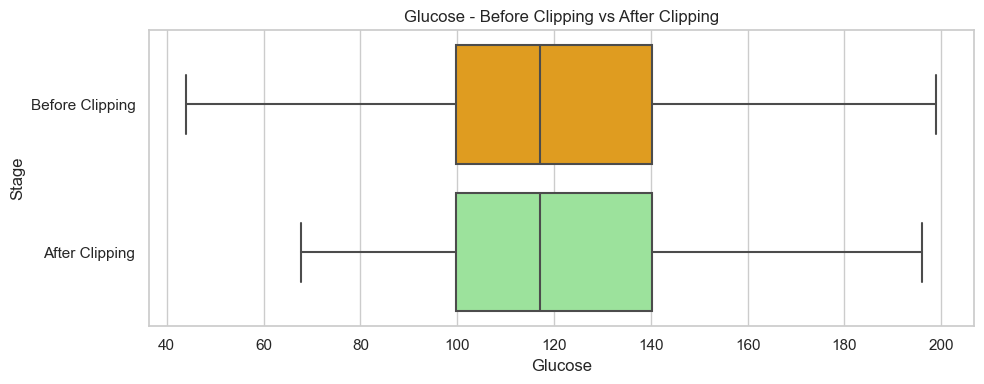

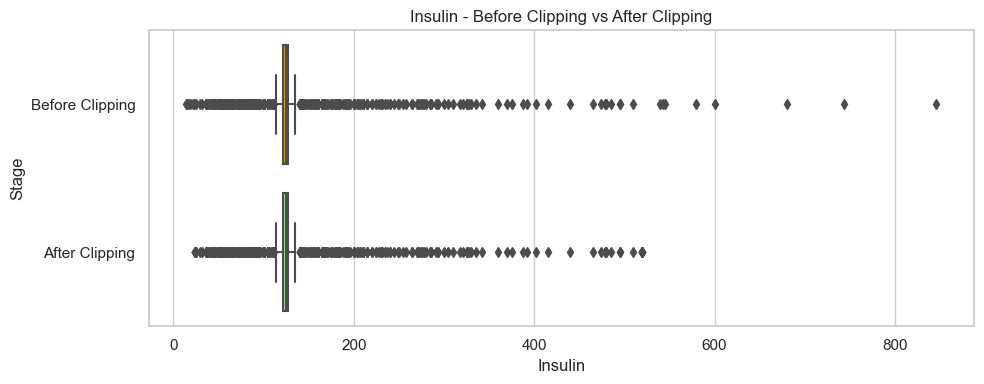

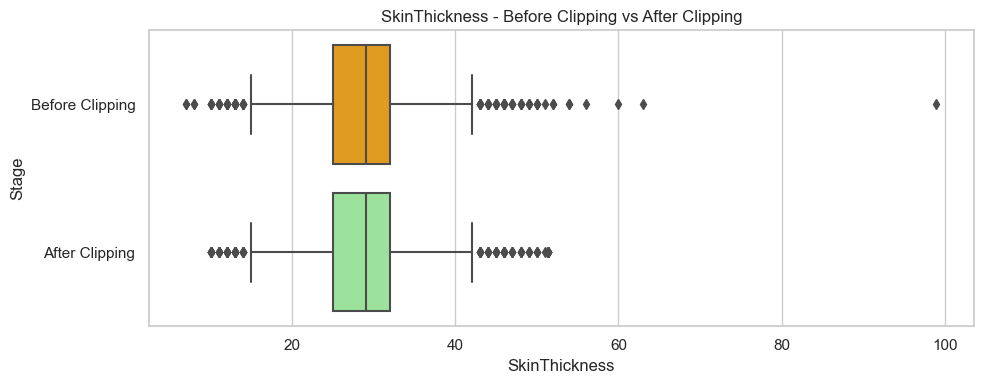

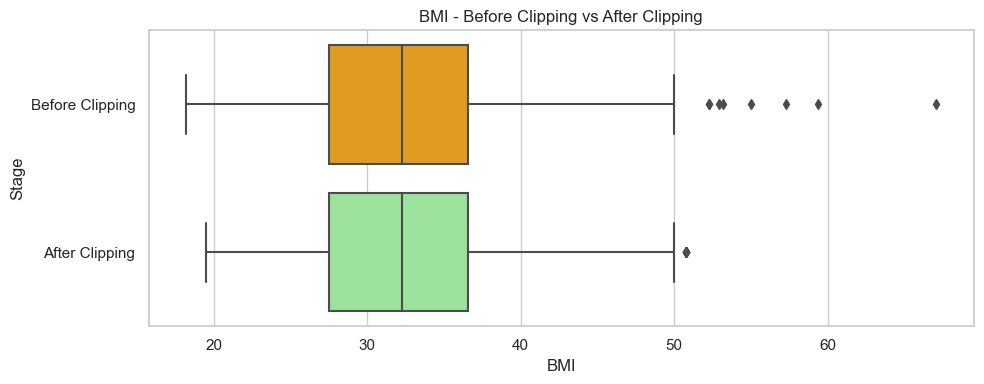

In [28]:
# Plot the results
plot_clipping_result(X_before_clipping, X_clipped, clip_ranges.keys(),
                     ["Before Clipping", "After Clipping"])

#### 1.4.3 Apply One-Sided Clipping for `Insulin`

After reviewing the distributions, we observed that the `Insulin` feature had residual extreme values on the upper end. We applied an additional one-sided clipping at the **95th percentile**, preserving valid low insulin cases.


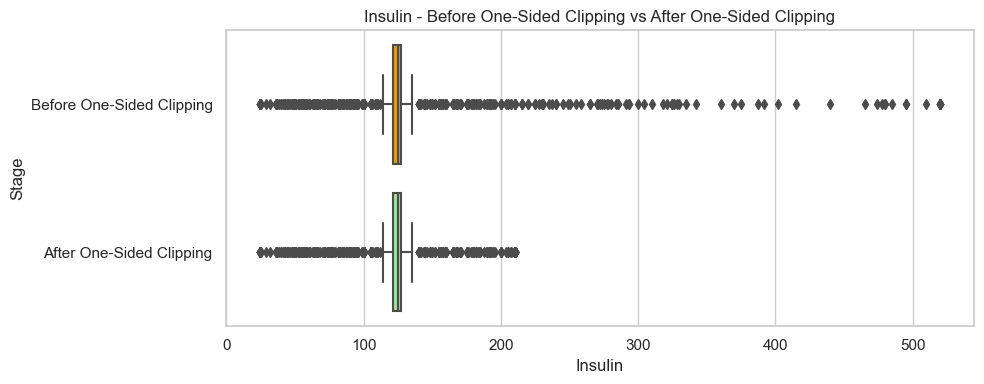

In [29]:
# One-sided clipping (upper only) for Insulin
one_sided_clip = {"Insulin": (None, 90)}
X_final, X_before_one_sided = apply_clipping(X_clipped.copy(), one_sided_clip)

plot_clipping_result(X_before_one_sided, X_final, ["Insulin"],
                     ["Before One-Sided Clipping", "After One-Sided Clipping"])

After reviewing the visual distribution, we decided to apply upper clipping at the 90th percentile for the `Insulin` feature.

- The distribution now shows significantly reduced outliers above 300, resulting in a more stable range for modeling.
- This adjustment helps minimize the risk of skewed model weights, especially for algorithms sensitive to input scale, such as logistic regression and SVM.


### 1.5 Split into Training & Testing Sets

Stratified split preserves the diabetic/non-diabetic class distribution in both training and test sets.

In [30]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.3, stratify=y, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (537, 8)
X_test shape: (231, 8)


We split the dataset while preserving the class distribution (stratify=y). **Stratified sampling** prevents bias in class distribution, especially crucial for imbalanced datasets like this one.

## 2. Model Definition & Hyperparameter Tuning

We define five candidate classifiers and apply GridSearchCV on selected hyperparameters.  
All models are wrapped in a standardized pipeline using `StandardScaler` for fair comparison.

### 2.1 Import Modeling Libraries

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### 2.2 Define Base Models

We begin by defining three models that do not require tuning for now:
- Random Forest
- Extra Trees
- SVM

Logistic Regression and Decision Tree will be tuned and added later.

In [32]:
# Define models with sensible initial settings
svm = SVC(probability=True, class_weight='balanced', random_state=42)
random_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
extra_trees = ExtraTreesClassifier(n_estimators=100, random_state=42)

### 2.3 Tune Decision Tree Depth via GridSearchCV

In this section, we use **GridSearchCV** to optimize key hyperparameters for two classifiers:

- **Decision Tree**: simple and interpretable model
- **Logistic Regression**: widely used baseline for linear decision boundaries

Tuning these models ensures fair comparison and enhances the performance of both standalone and ensemble models.

#### 2.3.1 Decision Tree Tuning

We tune the following parameters:

- `criterion`: `'gini'` vs `'entropy'`
- `max_depth`: odd integers from 3 to 19

We use a balanced class weight due to class imbalance.
Since tree-based models are not affected by feature scaling, we do not apply a scaler here.

In [33]:
# Grid search for Decision Tree (no scaling required)
decision_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Define hyperparameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': list(range(3, 20, 2))  # Odd depths only
}

# Grid search
grid_dt = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid_dt,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit the model
grid_dt.fit(X_train, y_train)

# Retrieve best model
best_params_dt = grid_dt.best_params_

print("Best Decision Tree Parameters:")
print(best_params_dt)

Best Decision Tree Parameters:
{'criterion': 'gini', 'max_depth': 7}


#### 2.3.2 Logistic Regression Tuning

Logistic regression is sensitive to feature scales, so we include `StandardScaler()` in the pipeline.

In [34]:
# Define pipeline for Logistic Regression with scaling
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)
)

# Define hyperparameter grid
param_grid_logreg = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_logreg,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fit the model
grid_logreg.fit(X_train, y_train)

# Retrieve best model
best_params_logreg = grid_logreg.best_params_
print("Best Logistic Regression Parameters:")
print(best_params_logreg)

Best Logistic Regression Parameters:
{'logisticregression__C': 1}


### 2.4 Finalize Models with Tuned Parameters

We now finalize our base model definitions by incorporating the best hyperparameters obtained through `GridSearchCV`.

- `DecisionTreeClassifier` uses the best combination of `criterion` and `max_depth`.
- `LogisticRegression` uses the best `C` value.

Since we will apply `StandardScaler` globally in the ensemble pipeline (Step 3), we don’t wrap it in a pipeline here.

These optimized base models will now be used in our ensemble voting classifier in the next step.

In [35]:
# Use the best hyperparameters found from grid search
decision_tree = DecisionTreeClassifier(
    criterion=best_params_dt['criterion'],
    max_depth=best_params_dt['max_depth'],
    class_weight='balanced',
    random_state=42
)

logreg = LogisticRegression(
    C=best_params_logreg['logisticregression__C'],
    class_weight='balanced',
    random_state=42
)

## 3. Soft Voting Ensemble

We build a **soft voting ensemble classifier**, which combines multiple classifiers by averaging their predicted probabilities.

- This ensemble includes both tuned and untuned models:
    - Tuned: `Logistic Regression`, `Decision Tree`
    - Untuned: `Random Forest`, `Extra Trees`, `SVM`
- We wrap the ensemble in a pipeline with StandardScaler() to ensure all models operate on standardized data.

This ensemble combines the **predictive power** of all five models and improves **generalization**.

In [36]:
# Define final voting classifier with all tuned components
voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('decision_tree', decision_tree),
        ('random_forest', random_forest),
        ('svm', svm),
        ('extra_trees', extra_trees)
    ],
    voting='soft'  # use predicted probabilities for voting
)

# Combine with scaling in a pipeline
pipeline = make_pipeline(StandardScaler(), voting_clf)

### 4. Train and Evaluate Base Ensemble Model

In this step, we train the soft voting ensemble built in Step 3 and evaluate its performance on the test set.

- We use a **classification report** and **confusion matrix** to analyze performance across both diabetic and non-diabetic classes.

- This baseline will later be compared against improved models using techniques like **threshold tuning** and **SMOTE**.

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       150
           1       0.64      0.63      0.63        81

    accuracy                           0.74       231
   macro avg       0.72      0.72      0.72       231
weighted avg       0.74      0.74      0.74       231

[[121  29]
 [ 30  51]]


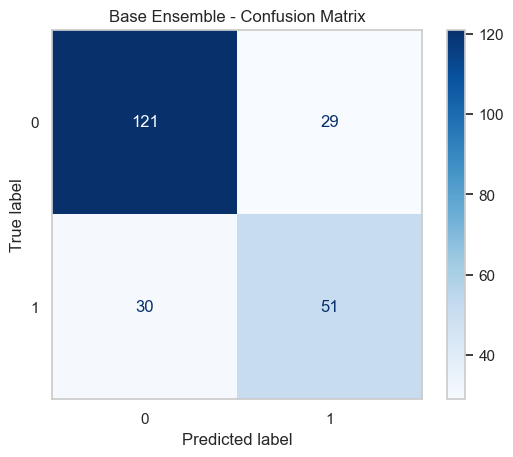

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Fit the pipeline on training data
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Evaluate performance
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap="Blues")
plt.title("Base Ensemble - Confusion Matrix")
plt.grid(False)
plt.show()


- True Negative (TN): 121 non-diabetic correctly predicted
- False Negative (FN): 30 diabetic misclassified as non-diabetic

False negatives are critical in medical use cases. We consider tuning thresholds or applying recall-boosting techniques.

## 5. Address Class Imbalance (SMOTE)

Our dataset has significantly more non-diabetic (class 0) than diabetic (class 1) cases.
To avoid bias toward the majority class and improve detection of diabetic patients, we apply **SMOTE** to balance the training set.

### 5.1 Apply SMOTE to Balance the Training Set

In [38]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Original:", np.bincount(y_train))
print("Resampled:", np.bincount(y_train_smote))


Original: [350 187]
Resampled: [350 350]


### 5.2 Visualize Class Distribution Before and After

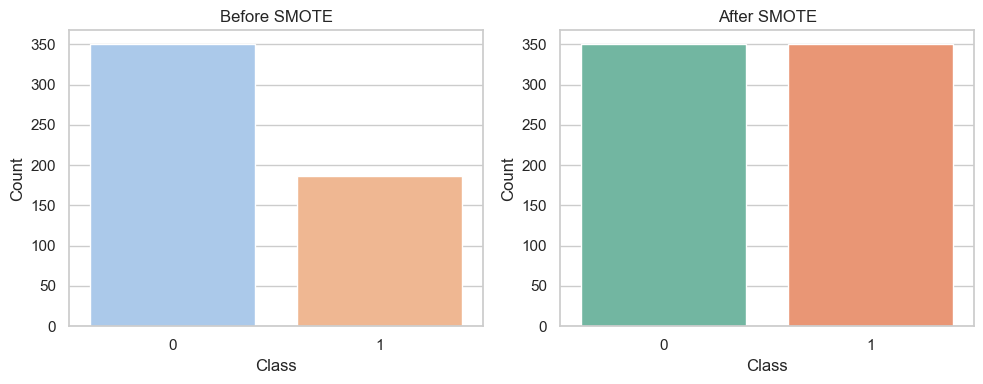

In [39]:
# Plot class distribution before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=y_train, ax=axes[0], palette='pastel')
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_smote, ax=axes[1], palette='Set2')
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 6. Rebuild Ensemble Using SMOTE Data

To evaluate the effect of class balancing, we retrain the soft voting ensemble using the SMOTE-augmented training data. This allows us to compare model performance with and without handling class imbalance.

### 6.1 Train Ensemble on SMOTE Data

In [40]:
# Use same base estimators with tuned hyperparameters
voting_clf_smote = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('random_forest', random_forest),
        ('svm', svm),
        ('decision_tree', decision_tree),
        ('extra_trees', extra_trees)
    ],
    voting='soft'
)

# Create pipeline with scaling
pipeline_smote = make_pipeline(StandardScaler(), voting_clf_smote)

# Fit on balanced training data
pipeline_smote.fit(X_train_smote, y_train_smote)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('votingclassifier',
                 VotingClassifier(estimators=[('logreg',
                                               LogisticRegression(C=1,
                                                                  class_weight='balanced',
                                                                  random_state=42)),
                                              ('random_forest',
                                               RandomForestClassifier(class_weight='balanced',
                                                                      random_state=42)),
                                              ('svm',
                                               SVC(class_weight='balanced',
                                                   probability=True,
                                                   random_state=42)),
                                              ('decision_tree',
                                               DecisionTreeClassifier(class_weight='balanced',
                                                                      max_depth=7,
                                                                      random_state=42)),
                                              ('extra_trees',
                                               ExtraTreesClassifier(random_state=42))],
                                  voting='soft'))])

### 6.2 Evaluate on Original Test Set

In [41]:
# Predict on test set
y_pred_smote = pipeline_smote.predict(X_test)

# Classification report1
print("Classification Report:\n")
print(classification_report(y_test, y_pred_smote))

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       150
           1       0.67      0.69      0.68        81

    accuracy                           0.77       231
   macro avg       0.75      0.75      0.75       231
weighted avg       0.77      0.77      0.77       231



### 6.3 Compare Ensemble Performance

| Model              | Recall (Class 1) | Precision (Class 1) | F1 Score (Class 1) | Accuracy |
|-------------------|------------------|----------------------|--------------------|----------|
| Base Ensemble      | 0.63             | 0.64                 | 0.63               | 0.74     |
| SMOTE Ensemble     | 0.69             | 0.67                 | 0.68               | 0.77     |

**Insights**:
- The SMOTE-based ensemble clearly improves **recall**, which is crucial for diabetic patient detection.
- Precision and F1 Score also increased, with a slight boost in overall accuracy.
- This justifies using SMOTE for training in screening-focused healthcare tasks.


## 7: Threshold Tuning for SMOTE Model

The default decision threshold of 0.5 may not be optimal for recall. We will experiment with **custom thresholds (0.5, 0.4, 0.35, 0.3)** to find the best recall-performance trade-off, especially for Class 1 (diabetic).

### 7.1 Predict with Multiple Thresholds

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

# Store results
thresholds = [0.5, 0.4, 0.35, 0.3]
reports = {}

# Get predicted probabilities
y_proba = pipeline_smote.predict_proba(X_test)[:, 1]

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    print(f"\n--- Threshold: {thresh} ---")
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    reports[thresh] = report
    print(classification_report(y_test, y_pred_thresh))
    cm = confusion_matrix(y_test, y_pred_thresh)
    print("Confusion Matrix:")
    print(cm)



--- Threshold: 0.5 ---
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       150
           1       0.67      0.69      0.68        81

    accuracy                           0.77       231
   macro avg       0.75      0.75      0.75       231
weighted avg       0.77      0.77      0.77       231

Confusion Matrix:
[[122  28]
 [ 25  56]]

--- Threshold: 0.4 ---
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       150
           1       0.61      0.83      0.70        81

    accuracy                           0.75       231
   macro avg       0.75      0.77      0.75       231
weighted avg       0.79      0.75      0.76       231

Confusion Matrix:
[[107  43]
 [ 14  67]]

--- Threshold: 0.35 ---
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       150
           1       0.60      0.85      0.70        81

    accuracy               

### 7.2 Visualize Metrics by Threshold

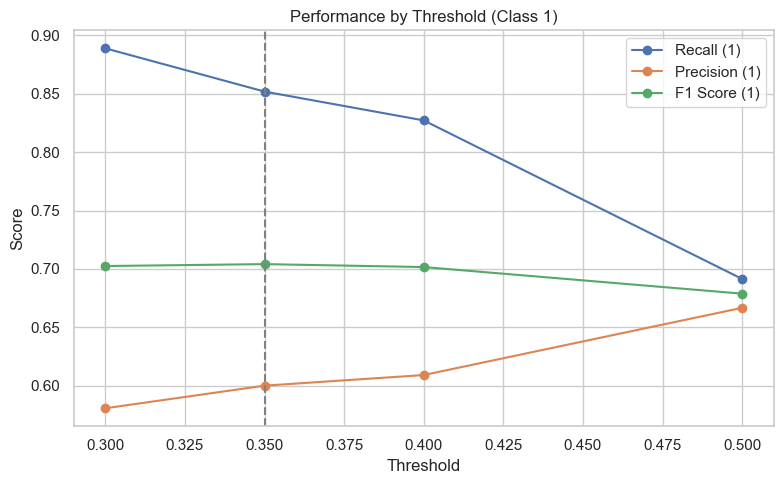

In [45]:
# Convert results to DataFrame for easy plotting
metric_df = pd.DataFrame({
    "Threshold": thresholds,
    "Recall (1)": [reports[t]['1']['recall'] for t in thresholds],
    "Precision (1)": [reports[t]['1']['precision'] for t in thresholds],
    "F1 Score (1)": [reports[t]['1']['f1-score'] for t in thresholds]
})

metric_df.set_index("Threshold", inplace=True)
metric_df.plot(marker='o', figsize=(8, 5))
plt.axvline(0.35, color='gray', linestyle='--', label='Selected Threshold (0.35)')
plt.title("Performance by Threshold (Class 1)")
plt.ylabel("Score")
plt.grid(True)
plt.tight_layout()
plt.show()


- Lowering the decision threshold improved recall significantly, confirming its importance in screening applications.  
- **Threshold = 0.35** offered the most favorable balance between high recall and acceptable precision.   
→ This threshold will be used for final interpretation and recommendation.

### 7.3 Visual Analysis of Optimal Threshold

#### 7.3.1 Recall vs Precision Trade-off

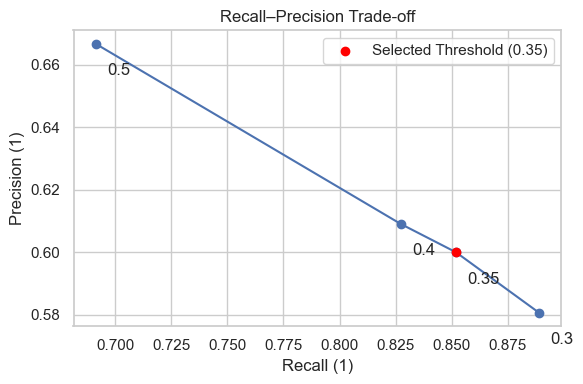

In [48]:
plt.figure(figsize=(6, 4))
plt.plot(metric_df['Recall (1)'], metric_df['Precision (1)'], marker='o')

# Annotate thresholds
for t in metric_df.index:
    plt.text(metric_df['Recall (1)'][t] + 0.005,
             metric_df['Precision (1)'][t] - 0.01,
             f"{t}")

# Highlight selected threshold
plt.scatter(metric_df['Recall (1)'][0.35], metric_df['Precision (1)'][0.35],
            color='red', label='Selected Threshold (0.35)', zorder=5)

plt.xlabel("Recall (1)")
plt.ylabel("Precision (1)")
plt.title("Recall–Precision Trade-off")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- The recall–precision curve visually highlights how lowering the threshold improves recall while reducing precision.
- Threshold `0.35` stands out with high recall (0.85) and moderate precision (0.60).

#### 7.3.2 Confusion Matrix at Selected Threshold

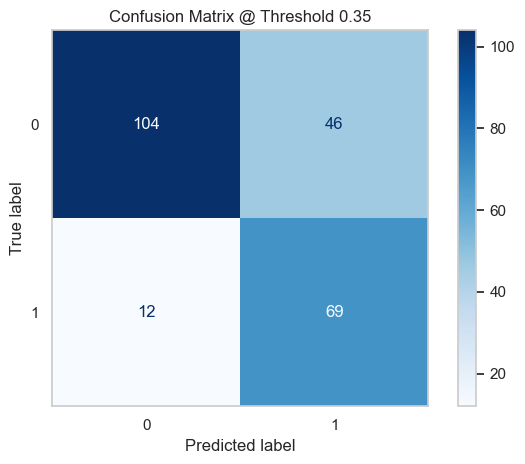

In [49]:
# Generate predictions with selected threshold
y_pred_035 = (y_proba >= 0.35).astype(int)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_035)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix @ Threshold 0.35")
plt.grid(False)
plt.tight_layout()
plt.show()



- The confusion matrix confirms a significant reduction in false negatives (FN = 12), critical for early detection.

#### 7.3.3 ROC Curve with Selected Threshold

The ROC curve illustrates the model's ability to distinguish between diabetic and non-diabetic cases across all thresholds.

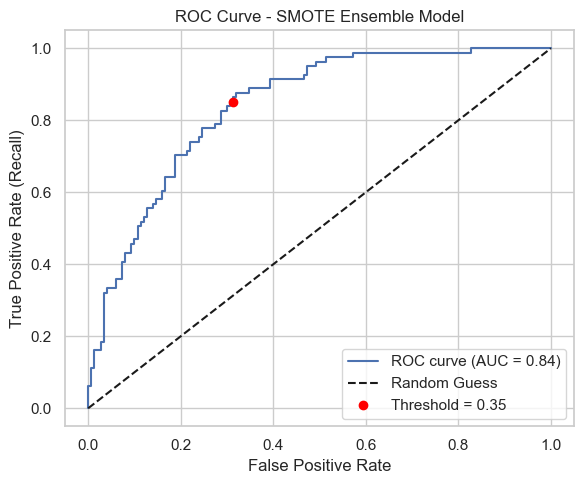

In [78]:
from sklearn.metrics import roc_curve, auc

# ROC Curve for SMOTE model
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Find index where threshold ≈ 0.35
threshold_target = 0.35
idx_closest = np.argmin(np.abs(thresholds_roc - threshold_target))
fpr_035 = fpr[idx_closest]
tpr_035 = tpr[idx_closest]

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")

# Highlight threshold = 0.35
plt.scatter(fpr_035, tpr_035, color='red', label=f"Threshold = {threshold_target}", zorder=5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SMOTE Ensemble Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- The model achieved an AUC of **0.84**, indicating strong discriminative performance.
- The red dot marks the operating point at **Threshold = 0.35**, where we selected the final model based on recall optimization.
- This visual confirmation supports the chosen threshold as a high-recall point with controlled false positives.

## 8. SHAP-Based Interpretability

Interpret the model using **SHAP (SHapley Additive exPlanations)** to:

- Understand which features drive the overall predictions
- Justify predictions for individual patients
- Support explainable AI in healthcare

To ensure compatibility with our ensemble (which includes non-tree models like SVM and Logistic Regression), we adopt **KernelExplainer**—a model-agnostic SHAP method that treats the model as a black box.

### 8.1 Standardize Data for SHAP

To ensure consistent feature scale for SHAP calculations, we standardize the training and test datasets. This step is critical because KernelExplainer relies on distance-based similarity between samples.

In [58]:
# Import SHAP
import shap

# Standardize training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### 8.2 Define SHAP KernelExplainer

We create a model-agnostic SHAP explainer using a small sample from the training data as background for simulating prediction behavior. This allows SHAP to estimate feature impact on probability outputs.

In [59]:
# Create prediction function for SHAP
rf_model = voting_clf_smote.named_estimators_['random_forest']
predict_fn = rf_model.predict_proba


# Sample 10 background points from training set
X_background = shap.sample(X_train_scaled_df, 10, random_state=42)

# Create KernelExplainer object
explainer = shap.KernelExplainer(predict_fn, X_background)

### 8.3 Compute and Plot Global SHAP Values

To reduce computation time, we use 50 test samples to calculate SHAP values and generate a summary plot that shows feature importance across predictions.

  0%|          | 0/50 [00:00<?, ?it/s]

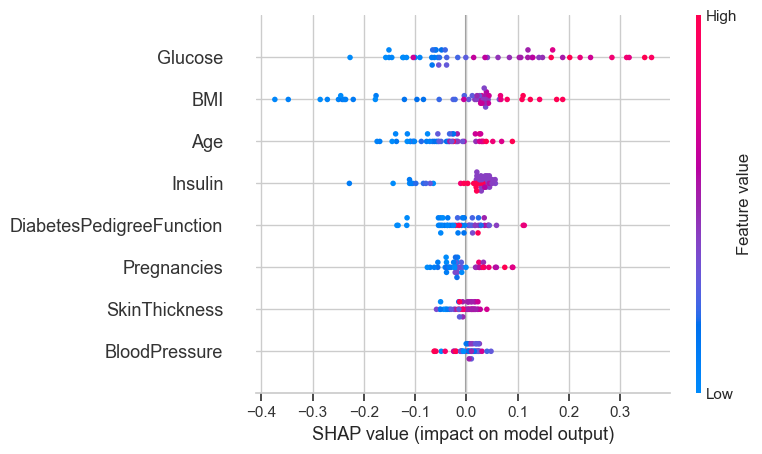

In [60]:
# Choose a manageable number of samples for explanation
X_subset = X_test_scaled_df.iloc[:50]  # Faster computation

# Compute SHAP values
shap_values = explainer.shap_values(X_subset)

# Extract SHAP values for class 1 (index 1)
shap_array = shap_values[:, :, 1]  # shape: (50, 8)

# Plot using correctly aligned input
shap.summary_plot(shap_array, X_subset)


The summary plot highlights how each feature influences the model’s prediction of diabetes across all patients.

- **Glucose** emerges as the most influential factor, with higher values consistently driving predictions toward class 1 (diabetic).
- **BMI** and **Age** also contribute positively—patients with higher values in these features are more likely to be classified as diabetic.
- In contrast, features such as **BloodPressure** and **SkinThickness** show minimal impact, indicating they play a lesser role in the model's decision-making.

Each dot in the plot represents one patient, with color reflecting the feature value (red = high, blue = low), and x-axis position indicating the direction and magnitude of influence.

### 8.4 Local Explanation (Patient-Level)

We used SHAP `force_plot()` to interpret a single patient's risk prediction.

- It highlights how much each feature pushes the prediction higher or lower.
- Clinicians can use this to justify the model’s output and validate its reasoning.

In [65]:
# Select a sample instance (e.g., first of 50 SHAP samples)
sample_idx = 0
sample = X_subset.iloc[sample_idx]

# Generate SHAP force plot for that sample
shap.initjs()  # Enable JS visualizations
shap.force_plot(
    base_value=explainer.expected_value[1],  # Base value for class 1 (diabetic)
    shap_values=shap_array[sample_idx],      # SHAP values for this sample
    features=sample,                         # Feature values
    feature_names=X_subset.columns
)

The model predicted a **28% probability** of diabetes for this patient.

- **Negative contributors**:
  - **Low insulin level** was the dominant factor pushing the prediction downward.
  - Additional negative influences included **low BMI**, **low skin thickness**, and **low diabetes pedigree function**.
- **Positive contributors**:
  - `Glucose` and `Age` had weak positive effects, but not enough to outweigh the negative predictors.

Overall, the patient’s profile showed stronger indicators of low risk, leading to a below-average probability score.

### 8.5 Local Feature vs Global Distribution

In the previous force plot (Step 8.4), the model predicted only **28% probability of diabetes** for a specific patient.

While global SHAP summary plots (Step 8.3) identified features like **Glucose**, **BMI**, and **Age** as top predictors, this individual case highlights how **local context** can shift feature importance.

Here, we compare the individual patient's values for `Insulin` and `Glucose` to the global feature distribution, explaining why certain features were more or less influential in this specific case.

#### 8.5.1 Global Distribution Comparison Function

In [74]:
# Function for plotting global distribution with sample overlay
def plot_feature_distribution(feature_name, sample_value, global_series, color="skyblue"):
    plt.figure(figsize=(10, 5))
    sns.histplot(global_series, kde=True, bins=30, color=color, edgecolor="black")
    plt.axvline(sample_value, color='red', linestyle='--', linewidth=2,
                label=f"Sample {feature_name} = {sample_value:.2f}")
    plt.title(f"{feature_name} Distribution in Dataset vs. Sample Patient")
    plt.xlabel(f"{feature_name} Value")
    plt.ylabel("Number of Patients")
    plt.legend()
    plt.tight_layout()
    plt.show()

#### 8.5.2 Visualize sameple value and global distribution

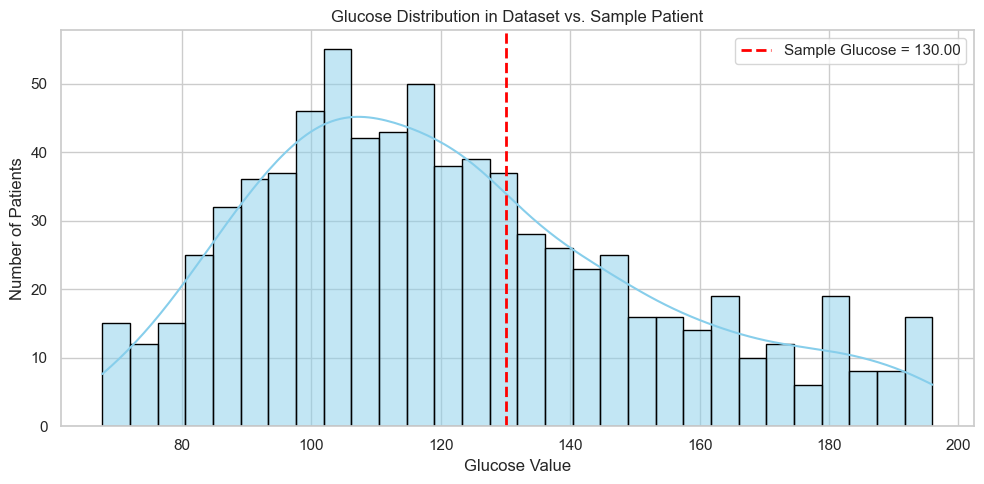

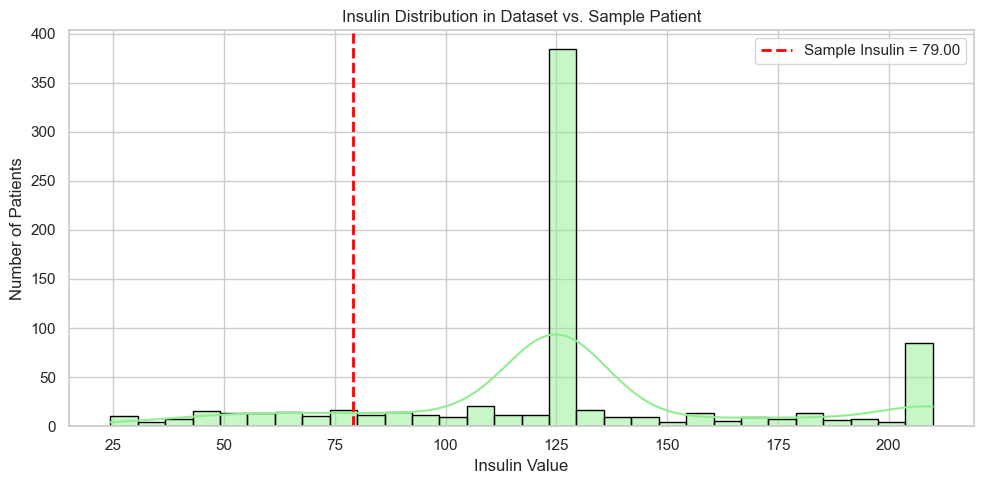

In [75]:
# Get the unscaled sample glucose value (after preprocessing, before standardization)
sample_glucose = X_test.iloc[sample_idx]["Glucose"]
sample_insulin = X_test.iloc[sample_idx]["Insulin"]

# Global feature series from cleaned data (before scaling)
glucose_series = X_final["Glucose"]
insulin_series = X_final["Insulin"]

# Plot for key features
plot_feature_distribution("Glucose", sample_glucose, glucose_series, color="skyblue")
plot_feature_distribution("Insulin", sample_insulin, insulin_series, color="lightgreen")

We visualized the patient's `Glucose` and `Insulin` levels relative to the entire dataset.

- **Glucose**:
    - The patient's value is **130** which is slightly above the population average.
    - This explains why glucose had only a **mild upward SHAP impact**—it was higher than average but not extreme enough to dominate the prediction.

- **Insulin**:
    - The patient has a significantly low insulin level, **79**.
    - Most patients have insulin levels clustered between 100 and 150, making this patient’s value **notably low**.
    - This rarity contributed to insulin having the **strongest negative SHAP value**, significantly pulling the prediction toward non-diabetic.


The ROC curve evaluates the model’s ability to distinguish between classes at various thresholds. AUC of 0.83 shows strong overall performance.

## 🔹Final Summary of Insights

This project successfully developed a recall-focused and interpretable machine learning model for early diabetes risk screening.

Key insights include:

- **Data Quality & Preprocessing**
  - Implausible zero values in clinical features were handled using median imputation.
  - Outliers were addressed using percentile-based clipping, including one-sided clipping for `Insulin` to reduce extreme upper values.

- **Modeling & Class Imbalance**
  - A soft voting ensemble was built using five classifiers, with hyperparameter tuning applied to Logistic Regression and Decision Tree.
  - Class imbalance was mitigated using SMOTE, which improved model recall without sacrificing interpretability.

- **Threshold Tuning**
  - Thresholds from 0.5 to 0.3 were evaluated.  
    The threshold of **0.35** achieved the best trade-off between **recall (0.85)** and **precision (0.60)**, making it ideal for screening applications.
  - ROC and precision–recall visualizations confirmed this as a high-recall, low-false-negative decision point.

- **Explainability**
  - SHAP analysis confirmed that **Glucose**, **BMI**, and **Age** were the most influential features—consistent with medical knowledge.
  - Patient-level force plots clearly demonstrated how individual predictions were made, enhancing model transparency.
  - Local values (e.g., Glucose = 130, Insulin = 79) were contextualized using global feature distributions, reinforcing the interpretability.

### 📌 Conclusion
The final model is well-suited as a clinical pre-screening tool, prioritizing recall and explainability.  
It enables early identification of at-risk individuals and supports human-in-the-loop decision-making in healthcare environments.
